In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("data/GOOG.csv")
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2022-12-22,88.930000,89.180000,86.940002,88.260002,88.260002,23656100
1,2022-12-23,87.620003,90.099998,87.620003,89.809998,89.809998,17815000
2,2022-12-27,89.309998,89.500000,87.535004,87.930000,87.930000,15470900
3,2022-12-28,87.500000,88.519997,86.370003,86.459999,86.459999,17879600
4,2022-12-29,87.029999,89.364998,86.989998,88.949997,88.949997,18280700


In [3]:
X = df.drop(columns=['Close', 'Date'])
y = df['Close']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

In [5]:
model = GradientBoostingRegressor(
    n_estimators=100,  
    learning_rate=0.1,      
    max_depth=3,           
    min_samples_split=2,    
    min_samples_leaf=1,    
    subsample=1.0,         
    random_state=21
)

R2 score 0.999774044176113
MSE 0.06232405976321644


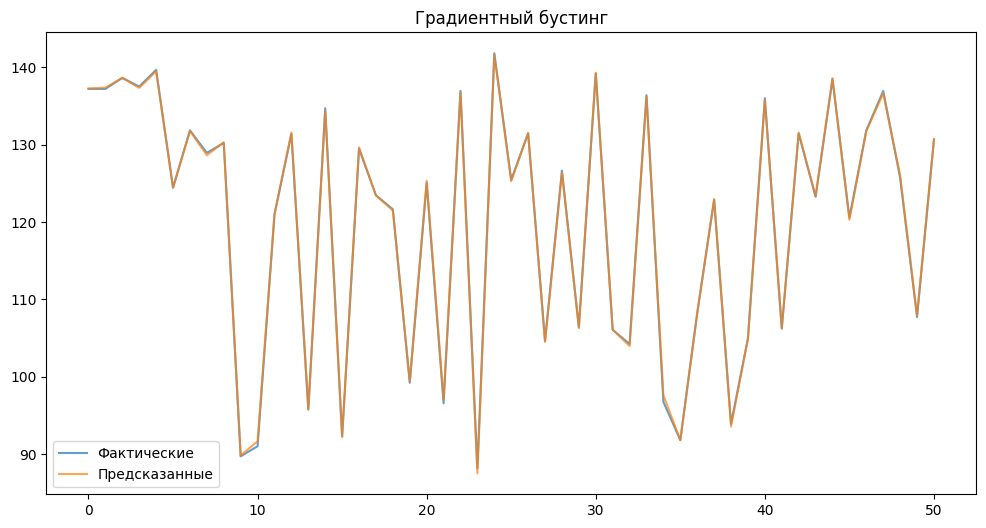

In [6]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"R2 score {r2}")
print(f"MSE {mse}")

plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label='Фактические', alpha=0.7)
plt.plot(y_pred, label='Предсказанные', alpha=0.7)
plt.legend()
plt.title(f'Градиентный бустинг')
plt.show()

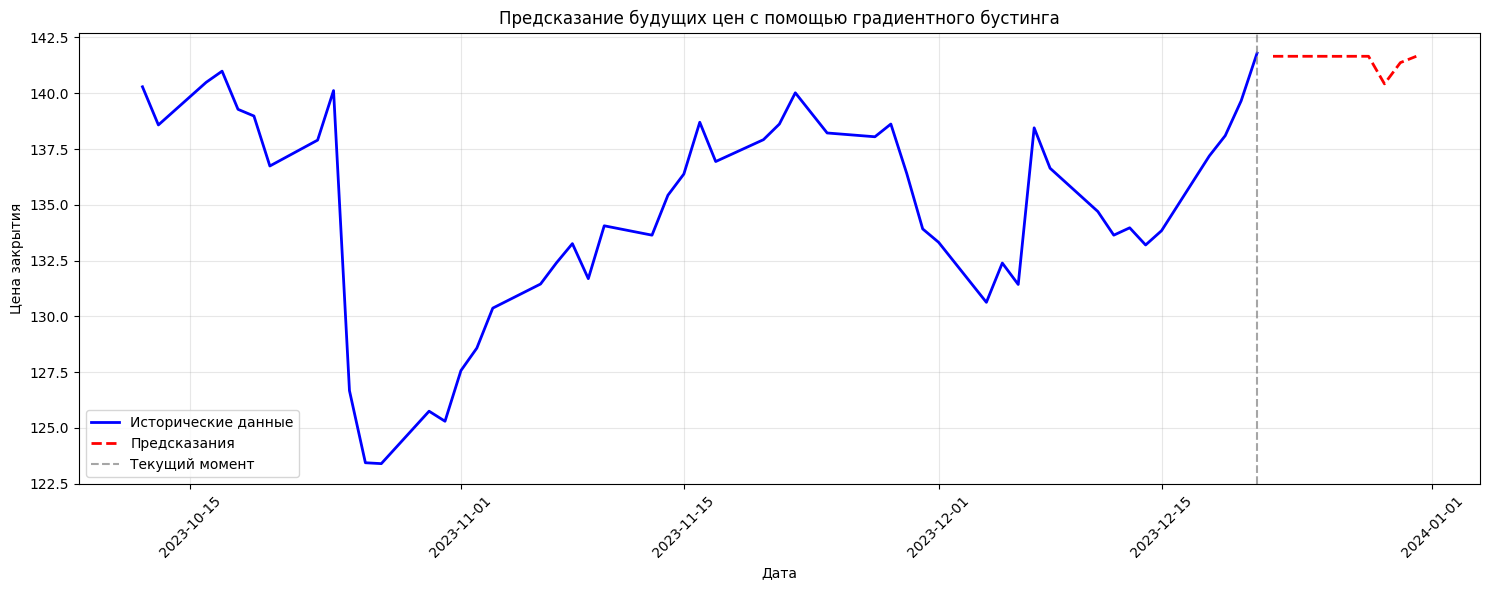

Предсказания на следующие 10 дней:
2023-12-22: 141.66
2023-12-23: 141.66
2023-12-24: 141.66
2023-12-25: 141.66
2023-12-26: 141.65
2023-12-27: 141.66
2023-12-28: 141.66
2023-12-29: 140.42
2023-12-30: 141.37
2023-12-31: 141.66


In [7]:
last_date = pd.to_datetime(df['Date'].iloc[-1])
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=10, freq='D')
new_data = pd.DataFrame()
for col in X.columns:
    last_values = X[col].iloc[-5:].values
    new_data[col] = [last_values[-1] + np.random.normal(0, 0.5) for _ in range(10)]

future_predictions = model.predict(new_data)
plt.figure(figsize=(15, 6))
historical_dates = pd.to_datetime(df['Date'].iloc[-50:])
historical_close = df['Close'].iloc[-50:]

plt.plot(historical_dates, historical_close, 'b-', label='Исторические данные', linewidth=2)
plt.plot(future_dates, future_predictions, 'r--', label='Предсказания', linewidth=2)

plt.axvline(x=historical_dates.iloc[-1], color='gray', linestyle='--', alpha=0.7, label='Текущий момент')
plt.xlabel('Дата')
plt.ylabel('Цена закрытия')
plt.title('Предсказание будущих цен с помощью градиентного бустинга')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print("Предсказания на следующие 10 дней:")
for date, pred in zip(future_dates, future_predictions):
    print(f"{date.strftime('%Y-%m-%d')}: {pred:.2f}")